
--- Feature Removal Plot for Clear Weather ---


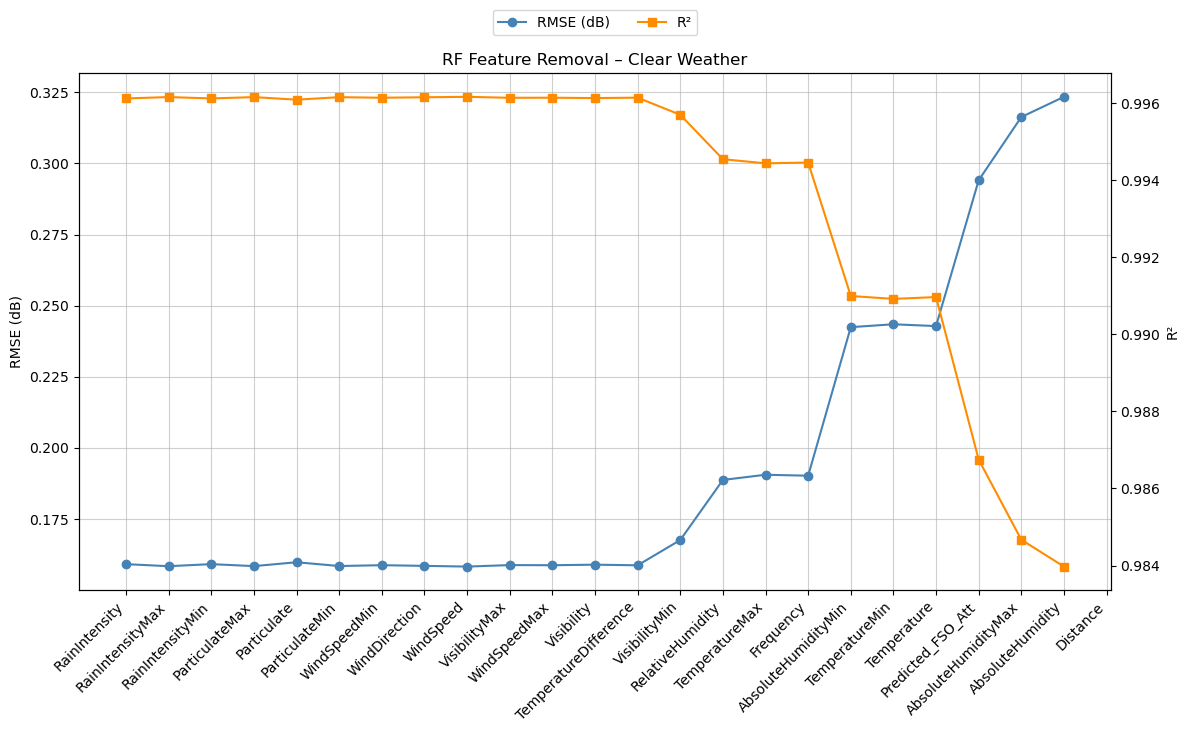


--- Feature Removal Plot for Duststorm ---


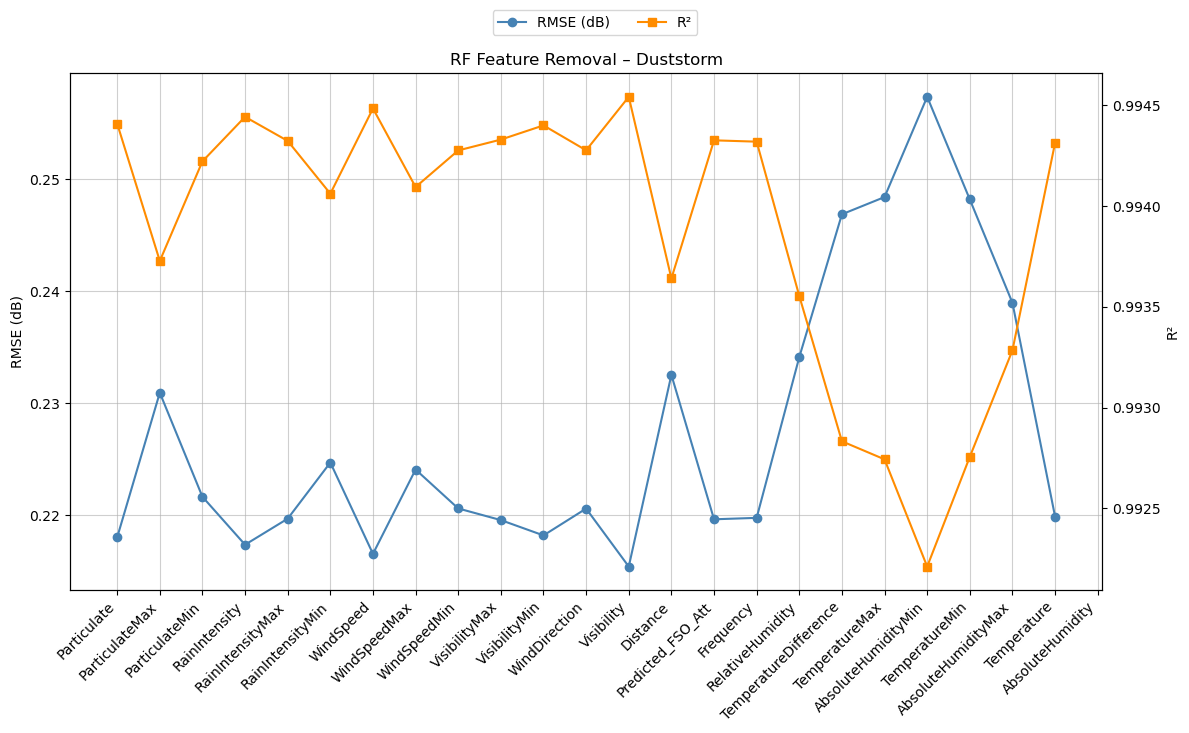


--- Feature Removal Plot for Fog ---


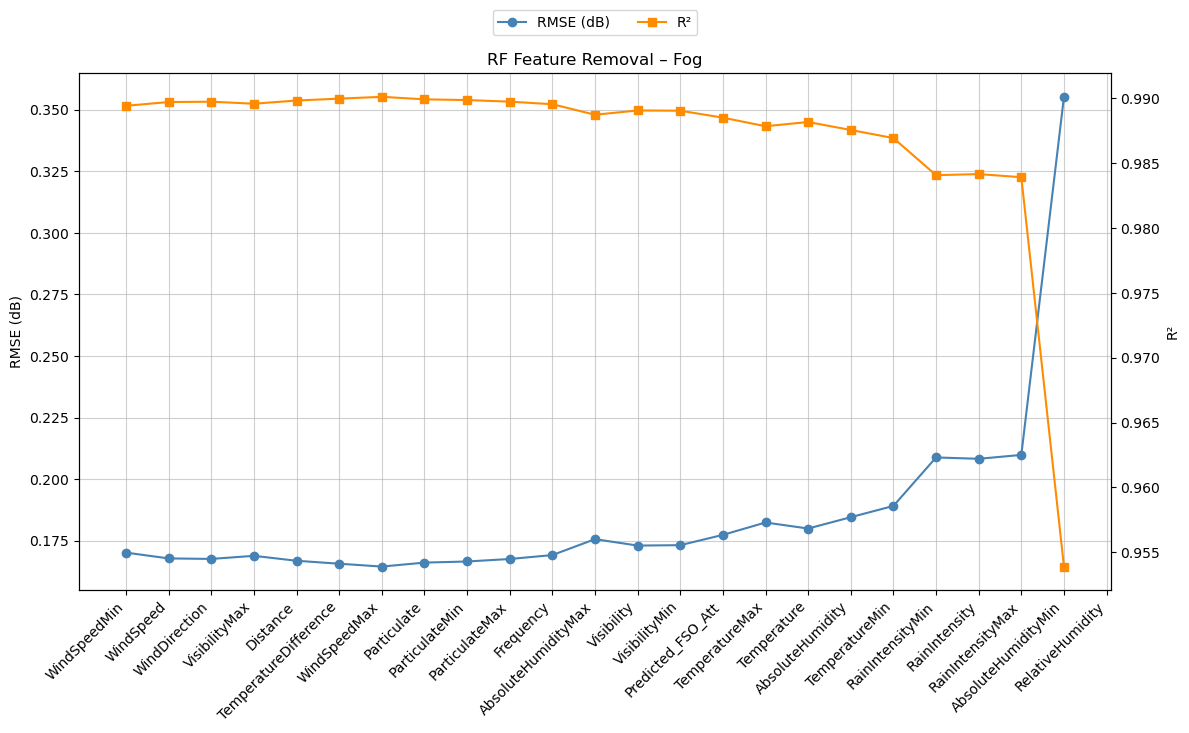


--- Feature Removal Plot for Drizzle ---


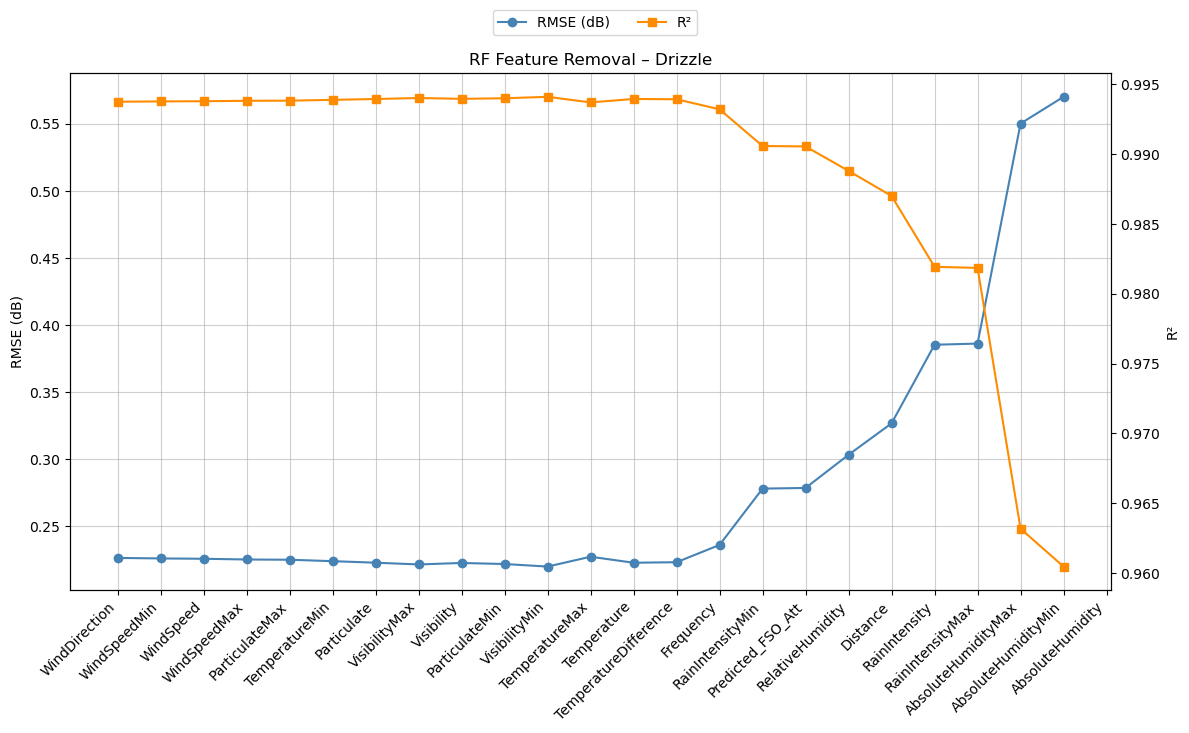


--- Feature Removal Plot for Rain ---


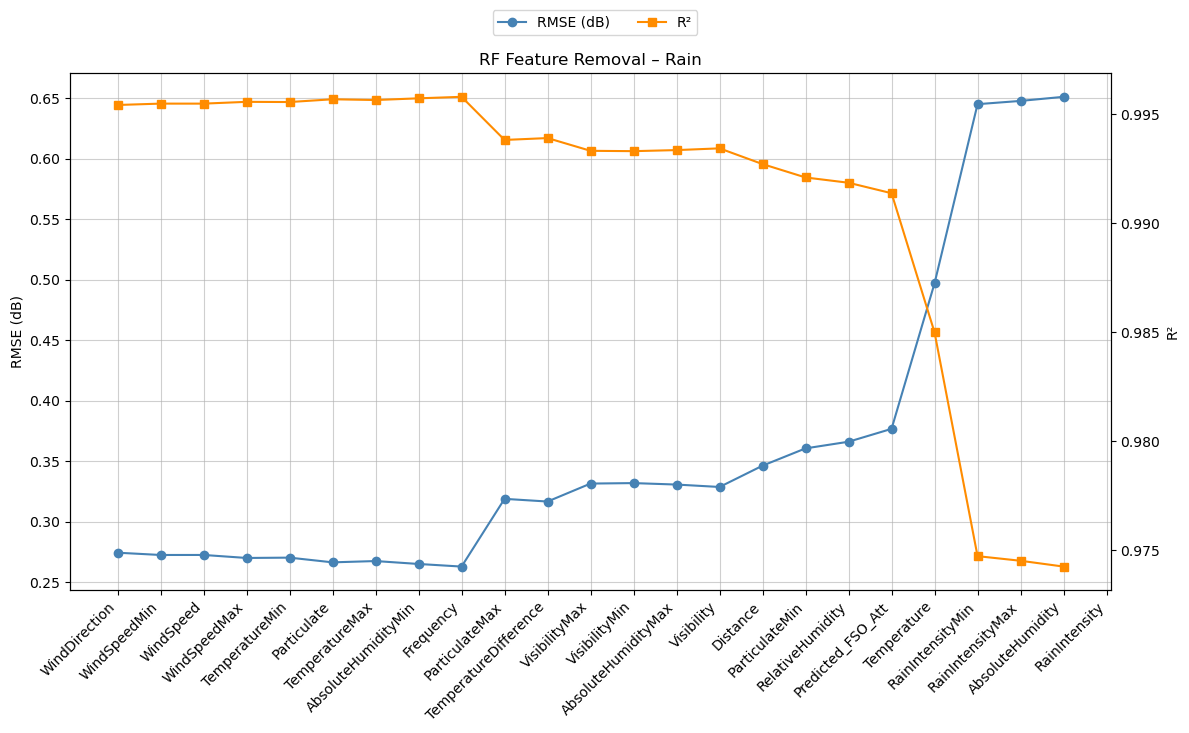


--- Feature Removal Plot for Snow ---


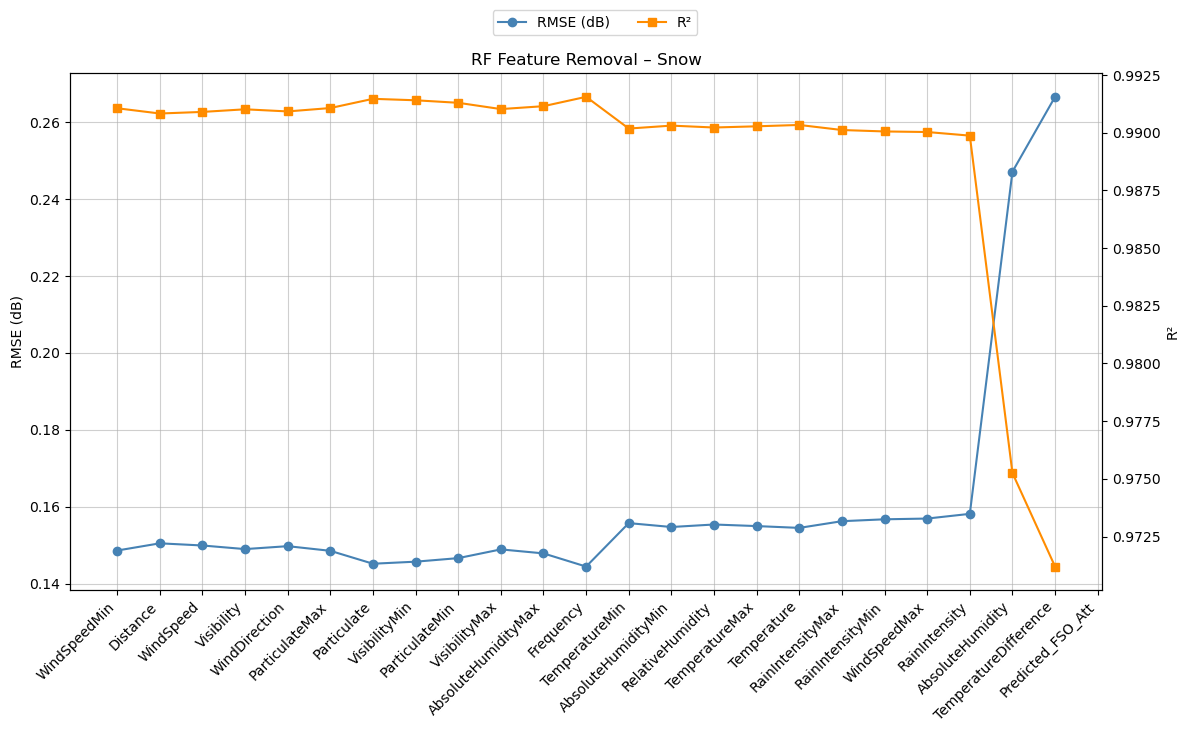


--- Feature Removal Plot for Showers ---


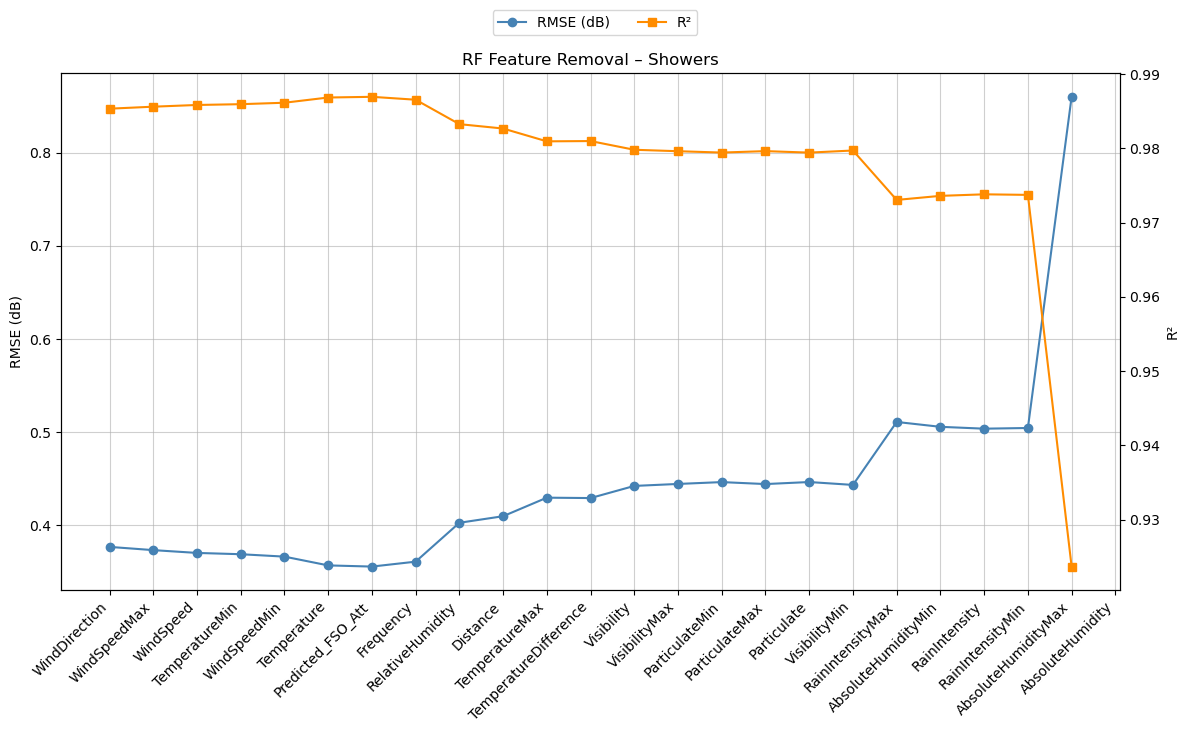

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.feature_selection import mutual_info_regression
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import pearsonr
import matplotlib.pyplot as plt


data = pd.read_csv("RFLFSODataFull.csv")  


weather_mapping = {
    0: 'Clear Weather',
    3: 'Duststorm',
    4: 'Fog',
    5: 'Drizzle',
    6: 'Rain',
    7: 'Snow',
    8: 'Showers'
}

fso_features_mapping = {
    0: ['AbsoluteHumidity', 'Visibility', 'TemperatureMax', 'VisibilityMin', 'VisibilityMax', 'TemperatureMin', 'Temperature', 'Distance'],
    3: ['Temperature', 'RelativeHumidity', 'Visibility', 'VisibilityMin', 'VisibilityMax', 'Distance'],
    4: ['WindSpeedMax', 'TemperatureMin', 'Temperature', 'Distance', 'ParticulateMax', 'ParticulateMin', 'Particulate'],
    5: ['Temperature', 'Visibility', 'ParticulateMax', 'Distance'],
    6: ['Visibility', 'Temperature', 'ParticulateMin', 'ParticulateMax', 'Particulate', 'Distance'],
    7: ['RelativeHumidity', 'WindSpeedMax', 'TemperatureDifference', 'ParticulateMax', 'ParticulateMin', 'Particulate'],
    8: ['Temperature', 'RelativeHumidity', 'VisibilityMax', 'Visibility', 'VisibilityMin', 'Distance']
}
param_dist = {
    'n_estimators': [50, 100, 200],
    'max_depth':    [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4]
}


def feature_removal_analysis(X, y, model, title):
    model.fit(X, y)
    importances = model.feature_importances_
    feats = np.array(X.columns)
    sorted_idx = np.argsort(importances)[::-1]
    sorted_feats = feats[sorted_idx]

    rmse_scores = []
    r2_scores   = []
    for i in range(len(sorted_feats), 1, -1):
        sel = sorted_feats[:i]
        model.fit(X[sel], y)
        y_pred = model.predict(X[sel])
        rmse_scores.append(np.sqrt(mean_squared_error(y, y_pred)))
        r2_scores.append(r2_score(y, y_pred))

  
    fig, ax1 = plt.subplots(figsize=(12,7))
    ln1 = ax1.plot(range(len(rmse_scores)), rmse_scores, marker='o',color='steelblue', label='RMSE (dB)')
    ax1.set_ylabel('RMSE (dB)')
    ax1.grid(alpha=0.6)

    ax2 = ax1.twinx()
    ln2 = ax2.plot(range(len(r2_scores)), r2_scores, marker='s', linestyle='-',color='darkorange', label='R²')
    ax2.set_ylabel('R²')

    ax1.set_xticks(range(len(sorted_feats)))
    ax1.set_xticklabels(sorted_feats[::-1], rotation=45, ha='right')

   
    lns = ln1 + ln2
    labels = [l.get_label() for l in lns]
    fig.legend(lns, labels, loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.05))

    plt.title(title)
    plt.tight_layout()
    plt.show()

    return sorted_feats, rmse_scores, r2_scores


for code, label in weather_mapping.items():
    subset = data[data['SYNOPCode'] == code]
    if len(subset) < 10:
        continue

    print(f"\n--- Feature Removal Plot for {label} ---")
    X = subset.drop(['RFL_Att','FSO_Att'], axis=1)
    y_fso = subset['FSO_Att']
    y_rf  = subset['RFL_Att']


    X_train, _, y_fso_train, _, y_rf_train, _ = train_test_split(
        X, y_fso, y_rf, test_size=0.2, random_state=42)

    fso_feats = fso_features_mapping[code]
    fso = RandomForestRegressor(n_estimators=200, random_state=42)
    fso.fit(X_train[fso_feats], y_fso_train)
    fso_pred = fso.predict(X_train[fso_feats])

    X_rf_in = X_train.drop(columns=['Time','SYNOPCode']).copy()
    X_rf_in['Predicted_FSO_Att'] = fso_pred

    feature_removal_analysis(
        X_rf_in, y_rf_train,
        RandomForestRegressor(random_state=42),
        f"RF Feature Removal – {label}"
    )




=== Final Results ===
         Weather  FSO RMSE    FSO R²   RF RMSE     RF R²  Pearson Corr (Real)  \
0  Clear Weather  1.145387  0.896653  0.442650  0.970155            -0.258470   
1      Duststorm  2.105350  0.949154  0.427984  0.983021            -0.594427   
2            Fog  1.032677  0.930985  0.585181  0.879684             0.571429   
3        Drizzle  1.045266  0.914609  0.673662  0.947284            -0.138306   
4           Rain  1.310778  0.905894  0.792499  0.960202             0.342100   
5           Snow  1.082893  0.956178  0.265199  0.961993             0.808386   
6        Showers  1.198088  0.902628  0.983669  0.887029            -0.250771   

   Pearson Corr (Pred)  Mutual Info (Real)  Mutual Info (Pred)  
0            -0.282238            0.036791            0.047138  
1            -0.571485            0.152279            0.102079  
2             0.581821            0.114233            0.143358  
3            -0.189577            0.049126            0.063884  
4  

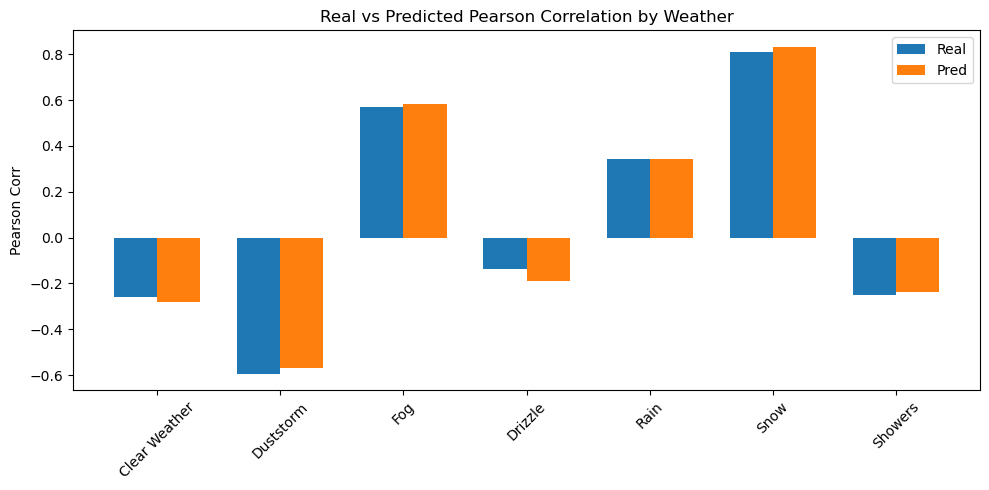

In [3]:
# 3. 
results = []
for code, label in weather_mapping.items():
    subset = data[data['SYNOPCode'] == code]
    if len(subset) < 10:
        continue

    # 1) 
    X = subset.drop(['RFL_Att','FSO_Att'], axis=1)
    y_fso = subset['FSO_Att']
    y_rf  = subset['RFL_Att']
    X_train, X_test, y_fso_train, y_fso_test, y_rf_train, y_rf_test = \
        train_test_split(X, y_fso, y_rf, test_size=0.2, random_state=42)

    # 2) 
    fso_search = RandomizedSearchCV(
        RandomForestRegressor(random_state=42), param_dist,
        n_iter=5, cv=2, scoring='neg_mean_squared_error',
        n_jobs=-1, random_state=42
    )
    fso_search.fit(X_train[fso_features_mapping[code]], y_fso_train)
    best_fso = fso_search.best_estimator_
    fso_pred_train = best_fso.predict(X_train[fso_features_mapping[code]])
    fso_pred_test  = best_fso.predict(X_test [fso_features_mapping[code]])

    # 3) 
    if code == 0:    # Clear Weather
        feats = ['TemperatureDifference', 'VisibilityMin', 'RelativeHumidity', 'TemperatureMax',
                 'Frequency', 'AbsoluteHumidityMin', 'TemperatureMin', 'Predicted_FSO_Att',
                 'Temperature', 'AbsoluteHumidityMax', 'AbsoluteHumidity', 'Distance']

    elif code == 3:  # Duststorm
        feats = ['Predicted_FSO_Att', 'Frequency', 'RelativeHumidity', 'TemperatureDifference',
                 'AbsoluteHumidityMin', 'TemperatureMax', 'AbsoluteHumidityMax',
                 'Temperature', 'AbsoluteHumidity']

    elif code == 4:  # Fog
        feats = ['VisibilityMin', 'Predicted_FSO_Att', 'VisibilityMax', 'Temperature',
                 'TemperatureMin', 'RainIntensityMax', 'RainIntensity', 'AbsoluteHumidityMin']

    elif code == 5:  # Drizzle
        feats = ['TemperatureDifference','Frequency', 'RainIntensityMin', 'Visibility', 'Distance',
                 'Predicted_FSO_Att', 'RainIntensity', 'RelativeHumidity',
                 'RainIntensityMax', 'AbsoluteHumidityMax', 'AbsoluteHumidityMin']

    elif code == 6:  # Rain
        feats = ['Frequency','ParticulateMax','TemperatureDifference','VisibilityMax',
                 'VisibilityMin','AbsoluteHumidityMax','Visibility', 'Distance',
                 'Predicted_FSO_Att', 'RainIntensity','RelativeHumidity',
                 'RainIntensityMax', 'AbsoluteHumidityMin']

    elif code == 7:  # Snow
        feats = ['Frequency','TemperatureMin', 'AbsoluteHumidityMin', 'RelativeHumidity',
                 'TemperatureMax','Temperature', 'RainIntensityMax', 'RainIntensityMin',
                 'WindSpeedMax','RainIntensity', 'AbsoluteHumidity',
                 'TemperatureDifference', 'Predicted_FSO_Att']

    else:           
        feats = ['Predicted_FSO_Att', 'Frequency', 'RelativeHumidity', 'Distance',
                 'TemperatureDifference', 'TemperatureMax', 'Visibility', 'VisibilityMax',
                 'ParticulateMin', 'ParticulateMax', 'Particulate', 'RainIntensityMin',
                 'RainIntensityMax', 'AbsoluteHumidityMax', 'AbsoluteHumidity']


    X_rf_train = X_train.drop(columns=['Time','SYNOPCode']).copy()
    X_rf_train['Predicted_FSO_Att'] = fso_pred_train
    X_rf_train = X_rf_train[feats]

    X_rf_test  = X_test.drop(columns=['Time','SYNOPCode']).copy()
    X_rf_test['Predicted_FSO_Att'] = fso_pred_test
    X_rf_test  = X_rf_test[feats]


    rf_search = RandomizedSearchCV(
        RandomForestRegressor(random_state=42), param_dist,
        n_iter=5, cv=2, scoring='neg_mean_squared_error',
        n_jobs=-1, random_state=42
    )
    rf_search.fit(X_rf_train, y_rf_train)
    best_rf     = rf_search.best_estimator_
    rf_test_pred = best_rf.predict(X_rf_test)


    fso_rmse = mean_squared_error(y_fso_test, fso_pred_test, squared=False)
    fso_r2   = r2_score(y_fso_test, fso_pred_test)
    rf_rmse  = mean_squared_error(y_rf_test, rf_test_pred, squared=False)
    rf_r2    = r2_score(y_rf_test, rf_test_pred)

    real_pear_corr = pearsonr(y_fso_test, y_rf_test)[0]
    pred_pear_corr = pearsonr(fso_pred_test, rf_test_pred)[0]

    real_mi_norm = mutual_info_regression(
        y_fso_test.values.reshape(-1,1), y_rf_test
    )[0] / np.log(len(y_fso_test))
    pred_mi_norm = mutual_info_regression(
        fso_pred_test.reshape(-1,1), rf_test_pred
    )[0] / np.log(len(fso_pred_test))

  
    results.append({
        'Weather': label,
        'FSO RMSE': fso_rmse,       'FSO R²': fso_r2,
        'RF RMSE': rf_rmse,         'RF R²': rf_r2,
        'Pearson Corr (Real)': real_pear_corr,
        'Pearson Corr (Pred)': pred_pear_corr,
        'Mutual Info (Real)': real_mi_norm,
        'Mutual Info (Pred)': pred_mi_norm
    })

#
results_df = pd.DataFrame(results)
print("\n=== Final Results ===")
print(results_df)

fig, ax = plt.subplots(figsize=(10,5))
x = np.arange(len(results_df))
width = 0.35
ax.bar(x-width/2, results_df['Pearson Corr (Real)'], width, label='Real')
ax.bar(x+width/2, results_df['Pearson Corr (Pred)'], width, label='Pred')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Weather'], rotation=45)
ax.set_ylabel('Pearson Corr')
plt.title('Real vs Predicted Pearson Correlation by Weather')
plt.legend()
plt.tight_layout()
plt.show()

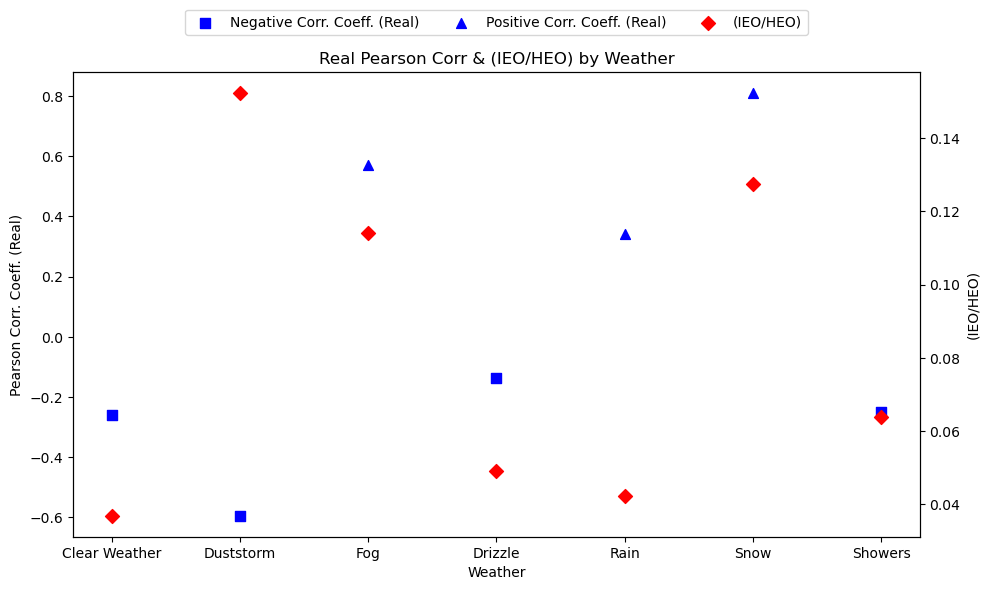

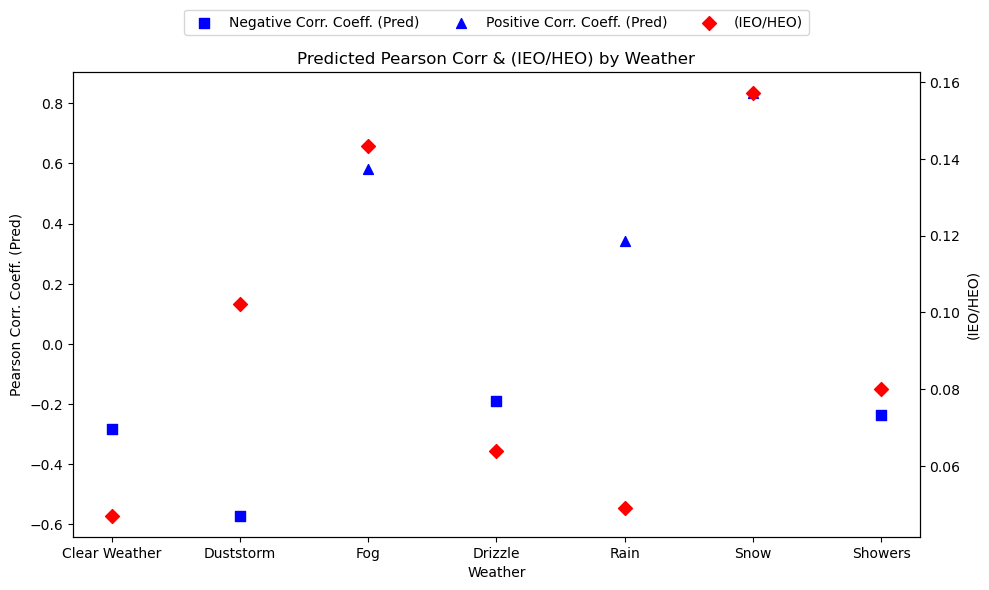

In [4]:
# 5.
desired_order = list(weather_mapping.values())
results_df['Weather'] = pd.Categorical(results_df['Weather'],
                                       categories=desired_order,
                                       ordered=True)
results_df.sort_values('Weather', inplace=True)

weathers   = results_df['Weather']
real_corr  = results_df['Pearson Corr (Real)']
pred_corr  = results_df['Pearson Corr (Pred)']
real_ieo   = results_df['Mutual Info (Real)']
pred_heo   = results_df['Mutual Info (Pred)']


def plot_corr_and_ieo_heo(ax_corr, ax_ieo_heo, weather_list, corr_values, ieo_heo_values,
                          title="", corr_label="", ieo_heo_ylabel="",
                          neg_label="", pos_label="", ieo_heo_label="",
                          markersize=50, rotation=0):
   
    x_positions = np.arange(len(weather_list))

    first_neg, first_pos = False, False
    for i, cval in enumerate(corr_values):
        if cval < 0:
            ax_corr.scatter(x_positions[i], cval, color='blue', marker='s',
                            s=markersize,
                            label=neg_label if not first_neg else "")
            first_neg = True
        else:
            ax_corr.scatter(x_positions[i], cval, color='blue', marker='^',
                            s=markersize,
                            label=pos_label if not first_pos else "")
            first_pos = True

 
    ax_ieo_heo.scatter(x_positions, ieo_heo_values, color='red', marker='D',
                       s=markersize, label=ieo_heo_label)

    ax_corr.set_title(title)
    ax_corr.set_xlabel("Weather")
    ax_corr.set_ylabel(corr_label)
    ax_ieo_heo.set_ylabel(ieo_heo_ylabel)

 
    ax_corr.set_xticks(x_positions)
    ax_corr.set_xticklabels(weather_list, rotation=rotation)

    handles_corr, labels_corr   = ax_corr.get_legend_handles_labels()
    handles_ieo, labels_ieo_heo = ax_ieo_heo.get_legend_handles_labels()
    combined = list(zip(handles_corr + handles_ieo, labels_corr + labels_ieo_heo))
    seen   = set()
    unique = []
    for (h, l) in combined:
        if l not in seen and l != "":
            unique.append((h, l))
            seen.add(l)

    ax_corr.legend([u[0] for u in unique],
                   [u[1] for u in unique],
                   loc='upper center',
                   bbox_to_anchor=(0.5, 1.15),  
                   ncol=3)                     


fig_real, ax_real_corr = plt.subplots(figsize=(10, 6))
ax_real_ieo_heo = ax_real_corr.twinx()
plot_corr_and_ieo_heo(
    ax_corr        = ax_real_corr,
    ax_ieo_heo     = ax_real_ieo_heo,
    weather_list   = weathers,
    corr_values    = real_corr,   
    ieo_heo_values = real_ieo,    
    title          = "Real Pearson Corr & (IEO/HEO) by Weather",
    corr_label     = "Pearson Corr. Coeff. (Real)",
    ieo_heo_ylabel = "(IEO/HEO)",         
    neg_label      = "Negative Corr. Coeff. (Real)",
    pos_label      = "Positive Corr. Coeff. (Real)",
    ieo_heo_label  = "(IEO/HEO)",          
    markersize     = 50,                   
    rotation       = 0
)
plt.tight_layout()
plt.show()

fig_pred, ax_pred_corr = plt.subplots(figsize=(10, 6))
ax_pred_ieo_heo = ax_pred_corr.twinx()
plot_corr_and_ieo_heo(
    ax_corr        = ax_pred_corr,
    ax_ieo_heo     = ax_pred_ieo_heo,
    weather_list   = weathers,
    corr_values    = pred_corr,   
    ieo_heo_values = pred_heo,    
    title          = "Predicted Pearson Corr & (IEO/HEO) by Weather",
    corr_label     = "Pearson Corr. Coeff. (Pred)",
    ieo_heo_ylabel = "(IEO/HEO)",
    neg_label      = "Negative Corr. Coeff. (Pred)",
    pos_label      = "Positive Corr. Coeff. (Pred)",
    ieo_heo_label  = "(IEO/HEO)",
    markersize     = 50,
    rotation       = 0
)
plt.tight_layout()
plt.show()

Generating heatmaps for Clear Weather (SYNOPCode=0), samples: 56964


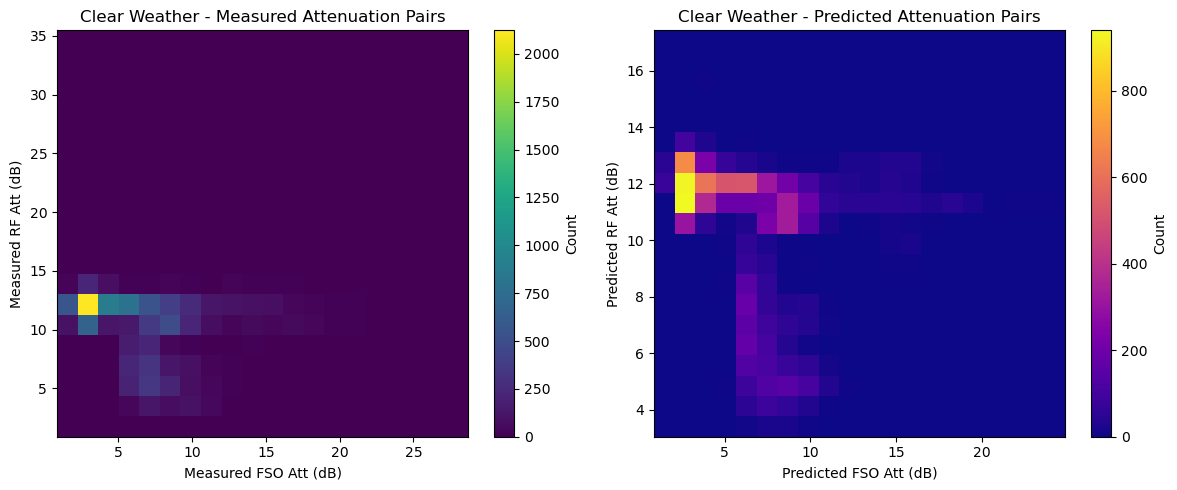

Generating heatmaps for Duststorm (SYNOPCode=3), samples: 191


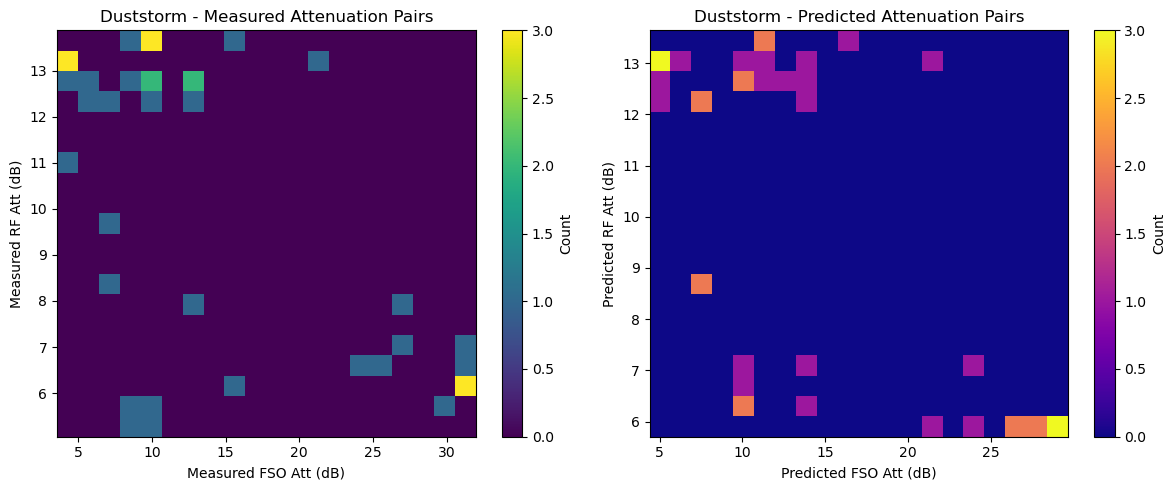

Generating heatmaps for Fog (SYNOPCode=4), samples: 466


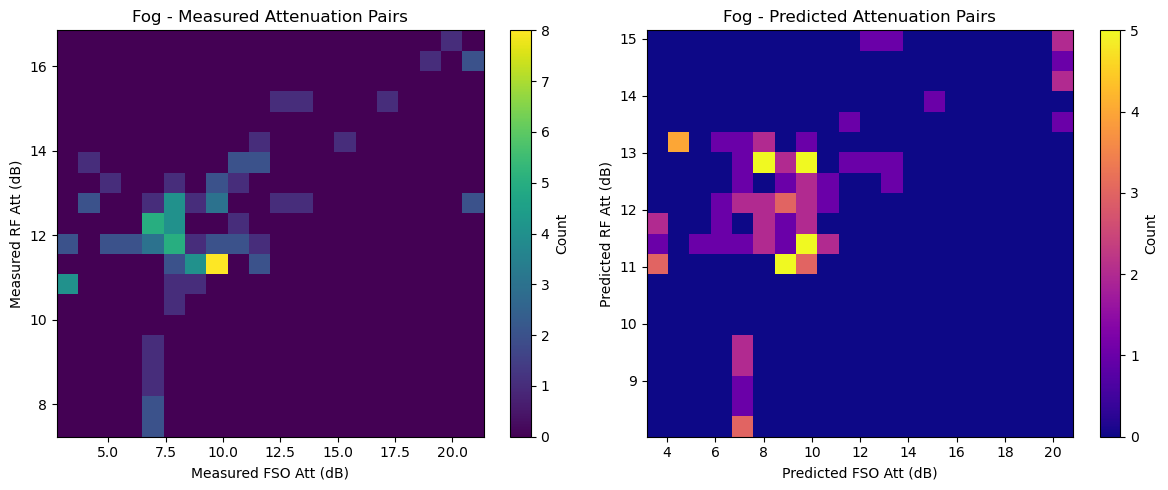

Generating heatmaps for Drizzle (SYNOPCode=5), samples: 6605


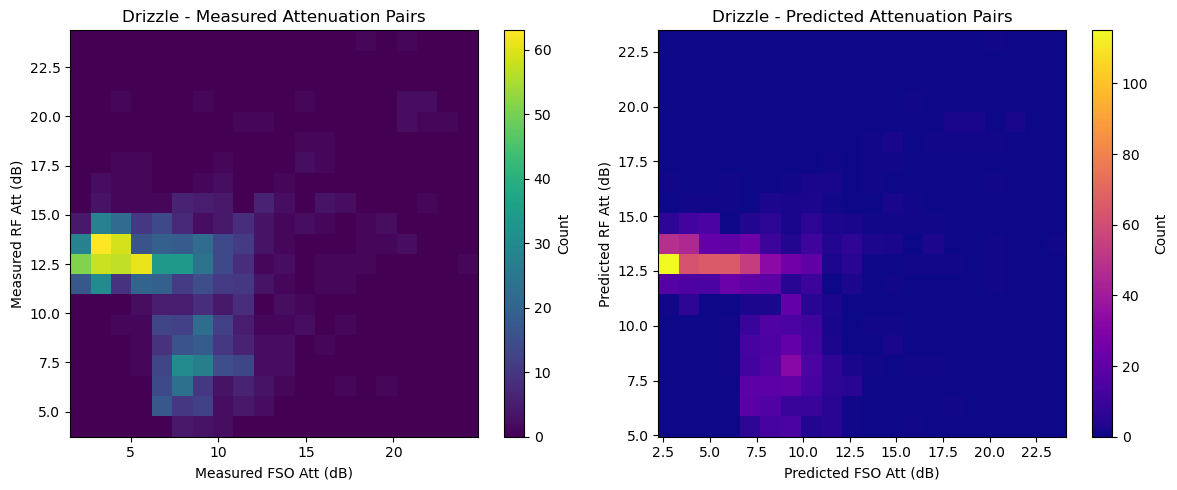

Generating heatmaps for Rain (SYNOPCode=6), samples: 25018


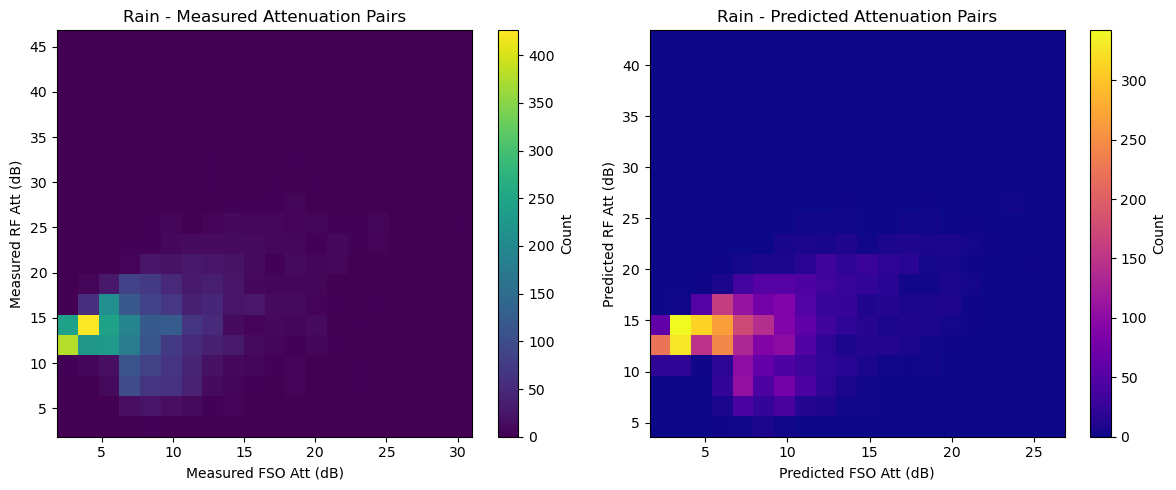

Generating heatmaps for Snow (SYNOPCode=7), samples: 419


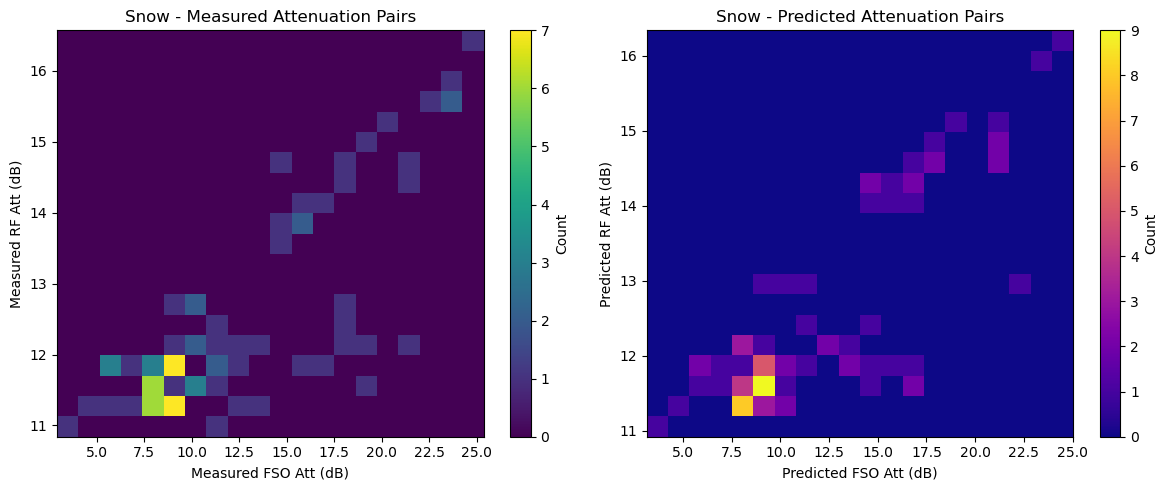

Generating heatmaps for Showers (SYNOPCode=8), samples: 1716


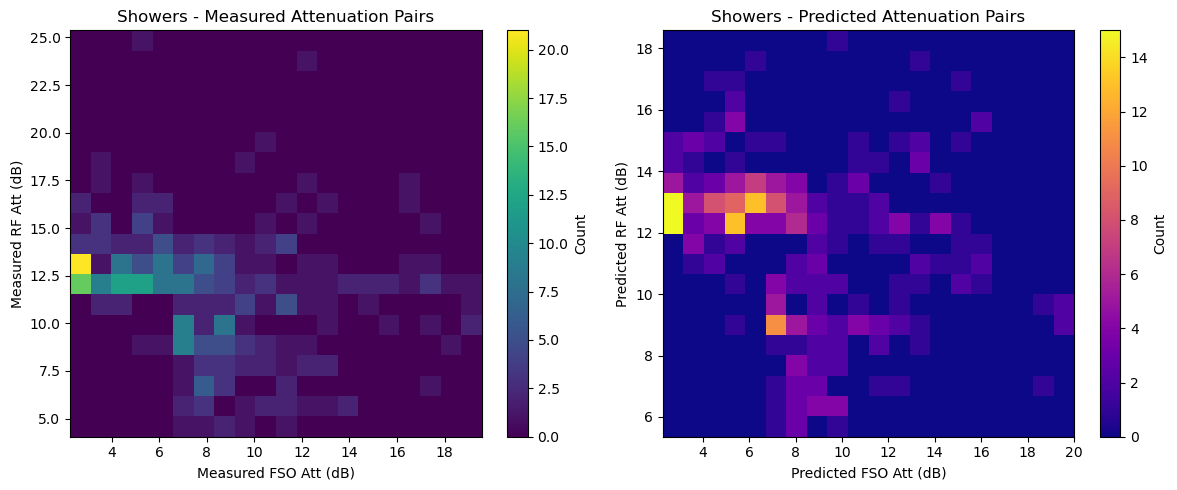

Generating heatmaps for ALL weather conditions combined.


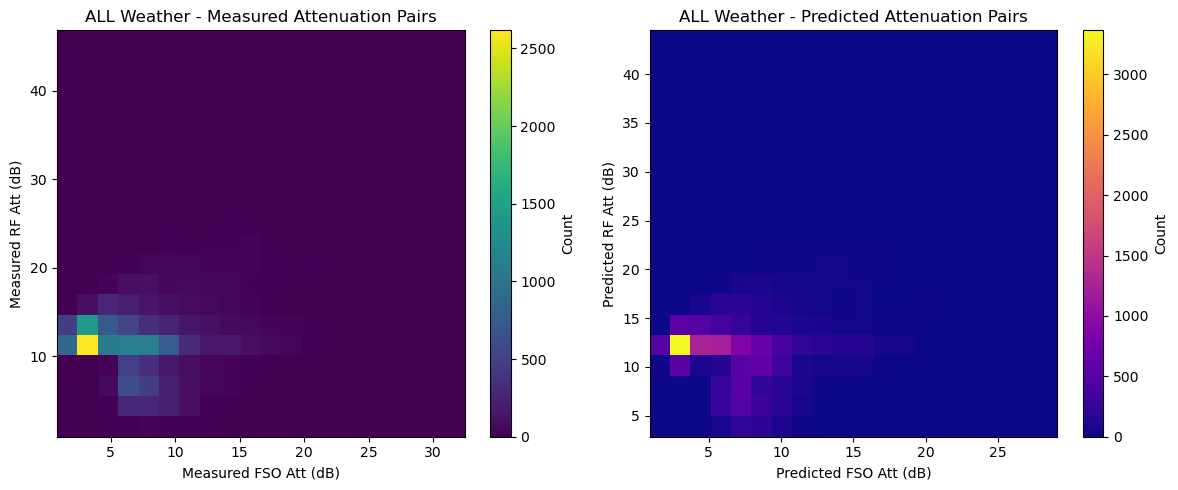

In [ ]:

import matplotlib.pyplot as plt

for code, label in weather_mapping.items():
    subset = data[data['SYNOPCode'] == code]
    if len(subset) < 10:
        print(f"Skipping {label} because sample size is too small.")
        continue
    print(f"Generating heatmaps for {label} (SYNOPCode={code}), samples: {len(subset)}")
    X_sub = subset.drop(['RFL_Att', 'FSO_Att'], axis=1)
    y_fso_sub = subset['FSO_Att']
    y_rf_sub  = subset['RFL_Att']
    X_train_sub, X_test_sub, y_fso_train_sub, y_fso_test_sub, y_rf_train_sub, y_rf_test_sub = train_test_split(
        X_sub, y_fso_sub, y_rf_sub, test_size=0.2, random_state=42
    )

    fso_feats_sub = fso_features_mapping[code]
    fso_model_heat = RandomForestRegressor(random_state=42)
    fso_model_heat.fit(X_train_sub[fso_feats_sub], y_fso_train_sub)
    fso_test_pred_sub = fso_model_heat.predict(X_test_sub[fso_feats_sub])

    X_train_rf_sub = X_train_sub.drop(columns=['Time','SYNOPCode']).copy()
    X_train_rf_sub['Predicted_FSO_Att'] = fso_model_heat.predict(X_train_sub[fso_feats_sub])
    X_train_rf_sub = X_train_rf_sub.iloc[:,:8]
    X_test_rf_sub = X_test_sub.copy()
    X_test_rf_sub['Predicted_FSO_Att'] = fso_test_pred_sub
    X_test_rf_sub = X_test_rf_sub.iloc[:,:8]
    rf_model_heat = RandomForestRegressor(random_state=42)
    rf_model_heat.fit(X_train_rf_sub, y_rf_train_sub)
    rf_test_pred_sub = rf_model_heat.predict(X_test_rf_sub)

    fig, axs = plt.subplots(1, 2, figsize=(12, 5))
    h1 = axs[0].hist2d(y_fso_test_sub, y_rf_test_sub, bins=20, cmap='viridis')
    axs[0].set_xlabel("Measured FSO Att (dB)")
    axs[0].set_ylabel("Measured RF Att (dB)")
    axs[0].set_title(f"{label} - Measured Attenuation Pairs")
    fig.colorbar(h1[3], ax=axs[0], label='Count')
    h2 = axs[1].hist2d(fso_test_pred_sub, rf_test_pred_sub, bins=20, cmap='plasma')
    axs[1].set_xlabel("Predicted FSO Att (dB)")
    axs[1].set_ylabel("Predicted RF Att (dB)")
    axs[1].set_title(f"{label} - Predicted Attenuation Pairs")
    fig.colorbar(h2[3], ax=axs[1], label='Count')
    plt.tight_layout()
    plt.show()

print("Generating heatmaps for ALL weather conditions combined.")
subset_all = data.copy()
X_all_heat = subset_all.drop(['RFL_Att', 'FSO_Att'], axis=1)
y_fso_all_heat = subset_all['FSO_Att']
y_rf_all_heat  = subset_all['RFL_Att']
X_train_all, X_test_all, y_fso_train_all, y_fso_test_all, y_rf_train_all, y_rf_test_all = train_test_split(
    X_all_heat, y_fso_all_heat, y_rf_all_heat, test_size=0.2, random_state=42
)
# FSO ALL
fso_feats_all = X_train_all.columns.drop(['Time','SYNOPCode']).tolist()
fso_model_all_heat = RandomForestRegressor(random_state=42)
fso_model_all_heat.fit(X_train_all[fso_feats_all], y_fso_train_all)
fso_test_pred_all = fso_model_all_heat.predict(X_test_all[fso_feats_all])
# RF ALL
X_train_rf_all = X_train_all.drop(columns=['Time','SYNOPCode']).copy()
X_train_rf_all['Predicted_FSO_Att'] = fso_model_all_heat.predict(X_train_all[fso_feats_all])
X_train_rf_all = X_train_rf_all.iloc[:,:8]
X_test_rf_all = X_test_all.copy()
X_test_rf_all['Predicted_FSO_Att'] = fso_test_pred_all
X_test_rf_all = X_test_rf_all.iloc[:,:8]
rf_model_all_heat = RandomForestRegressor(random_state=42)
rf_model_all_heat.fit(X_train_rf_all, y_rf_train_all)
rf_test_pred_all = rf_model_all_heat.predict(X_test_rf_all)
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
h1_all = axs[0].hist2d(y_fso_test_all, y_rf_test_all, bins=20, cmap='viridis')
axs[0].set_xlabel("Measured FSO Att (dB)")
axs[0].set_ylabel("Measured RF Att (dB)")
axs[0].set_title("ALL Weather - Measured Attenuation Pairs")
fig.colorbar(h1_all[3], ax=axs[0], label='Count')
h2_all = axs[1].hist2d(fso_test_pred_all, rf_test_pred_all, bins=20, cmap='plasma')
axs[1].set_xlabel("Predicted FSO Att (dB)")
axs[1].set_ylabel("Predicted RF Att (dB)")
axs[1].set_title("ALL Weather - Predicted Attenuation Pairs")
fig.colorbar(h2_all[3], ax=axs[1], label='Count')
plt.tight_layout()
plt.show()
